# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Marek Rosberg
* Username: mrosberg
* Student number: S6200060
* Group (AS1, etc.): AS1

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

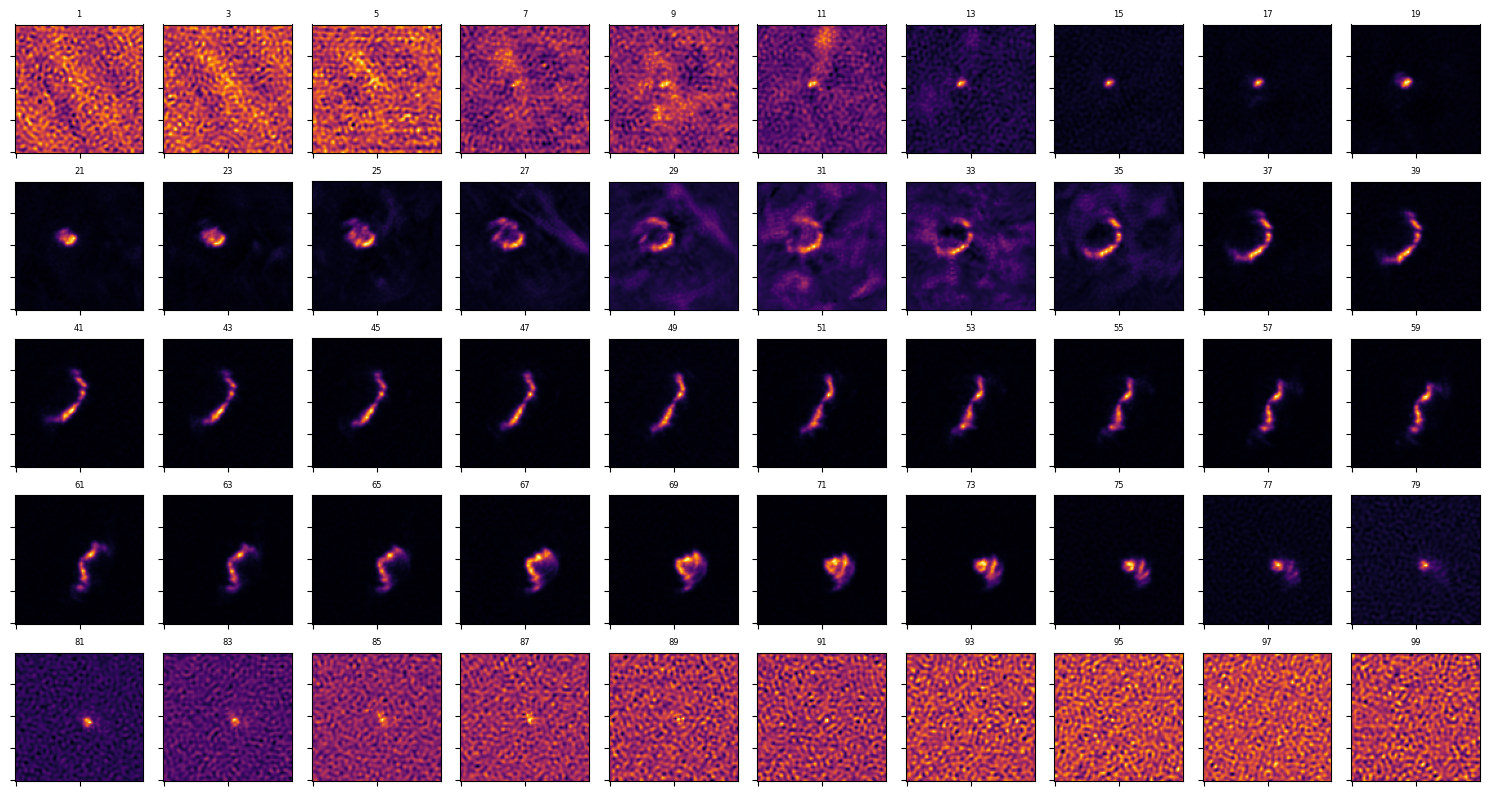

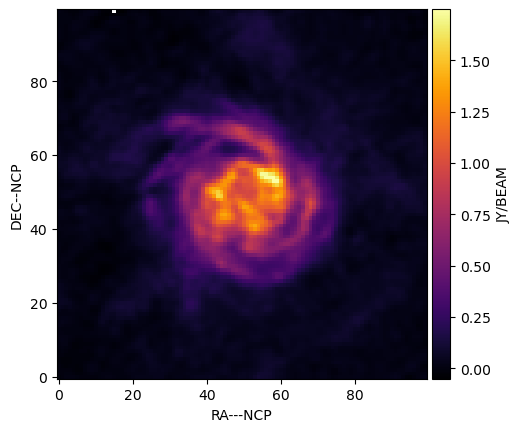

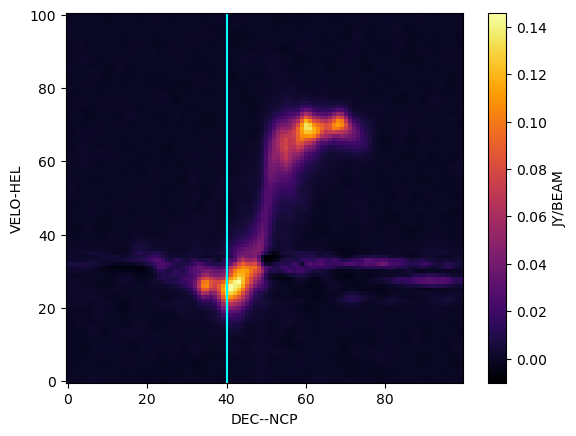

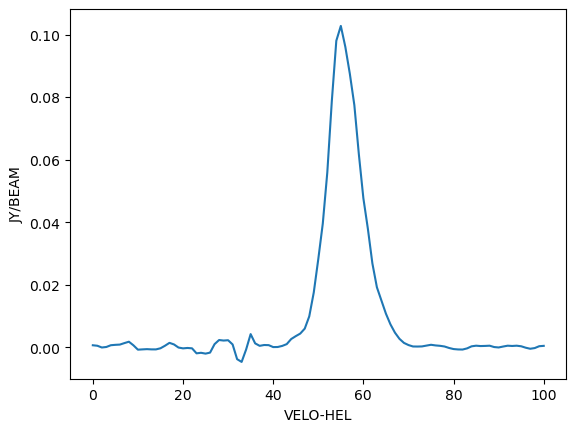

In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

hdul = fits.open("ngc6946.fits")
data = hdul[0].data
header = hdul[0].header

# ------------------ MOSAIC ------------------
channels = range(1, 101, 2)

fig, axes = plt.subplots(5, 10, figsize=(15, 8))

for i, ax in enumerate(axes.flat):
    ch = channels[i]
    ax.imshow(data[ch], origin='lower', cmap='inferno')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(f"{ch}", fontsize=6)

plt.tight_layout()
plt.show()


# ------------------ TOTAL HI MAP ------------------
# Choosing signal range by inspecting mosaic (avoiding noisy edges)
signal_channels = range(20, 80)

total_map = np.sum(data[signal_channels], axis=0)

fig, ax = plt.subplots()
im = ax.imshow(total_map, origin='lower', cmap='inferno')

ax.set_xlabel(header['CTYPE1'])
ax.set_ylabel(header['CTYPE2'])

# Locatable colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label(header['BUNIT'])

plt.show()


# ------------------ PV MAP (fixed RA) ------------------
pv_map = data[:, 50, :]  # FIXED RA

fig, ax = plt.subplots()
im = ax.imshow(pv_map, origin='lower', aspect='auto', cmap='inferno')

ax.axvline(x=40, color='cyan')

ax.set_xlabel(header['CTYPE2'])
ax.set_ylabel(header['CTYPE3'])

plt.colorbar(im, label=header['BUNIT'])
plt.show()


# ------------------ GLOBAL PROFILE ------------------
profile = data[:, 40, 50]

fig, ax = plt.subplots()
ax.plot(profile)

ax.set_xlabel(header['CTYPE3'])
ax.set_ylabel(header['BUNIT'])

plt.show()

The global HI profile corresponds to the vertical slice in the PV diagram at Dec index 40. The vertical line selects a single spatial position, and the profile shows the intensity as a function of velocity at that position. Thus, the profile is effectively a 1D extraction of the PV map along that line.

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

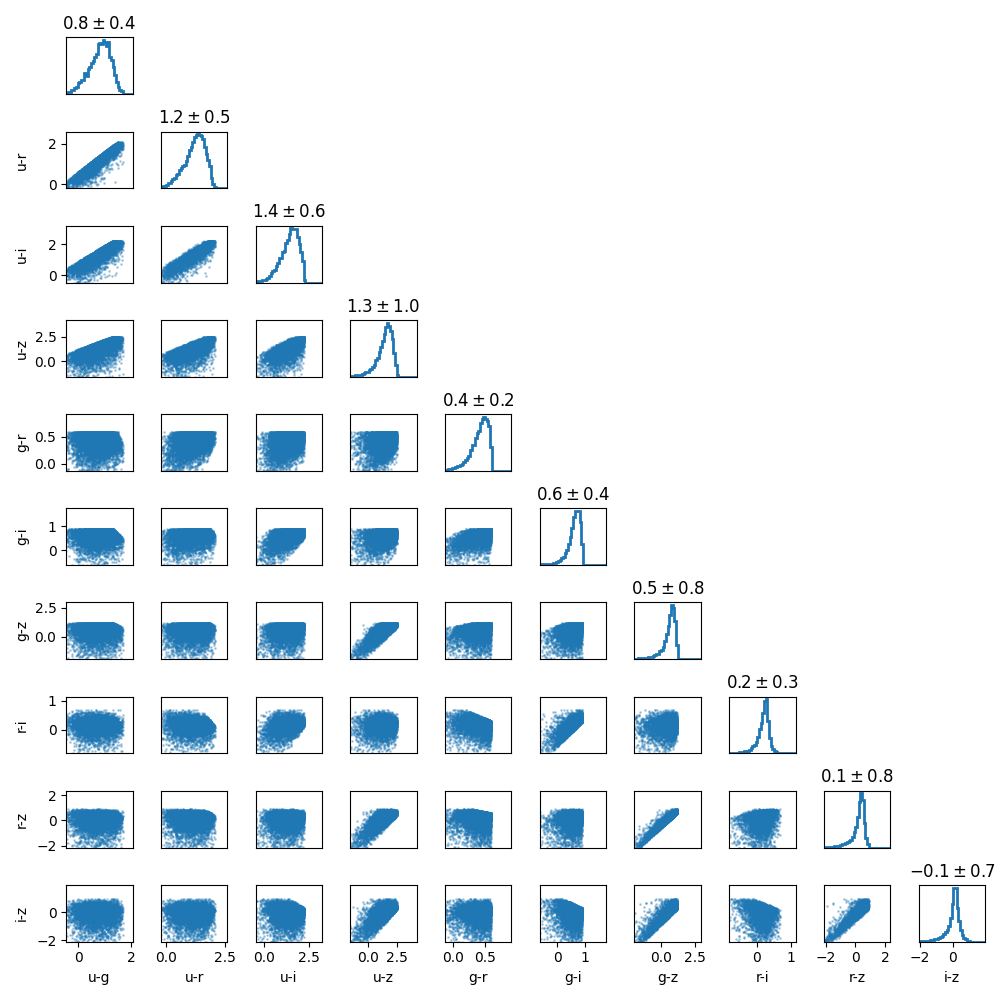
   
**Plot and answer**:

Available columns: ['ObjID', 'u', 'g', 'r', 'i', 'z']
Using bands: ['u', 'g', 'r', 'i', 'z']


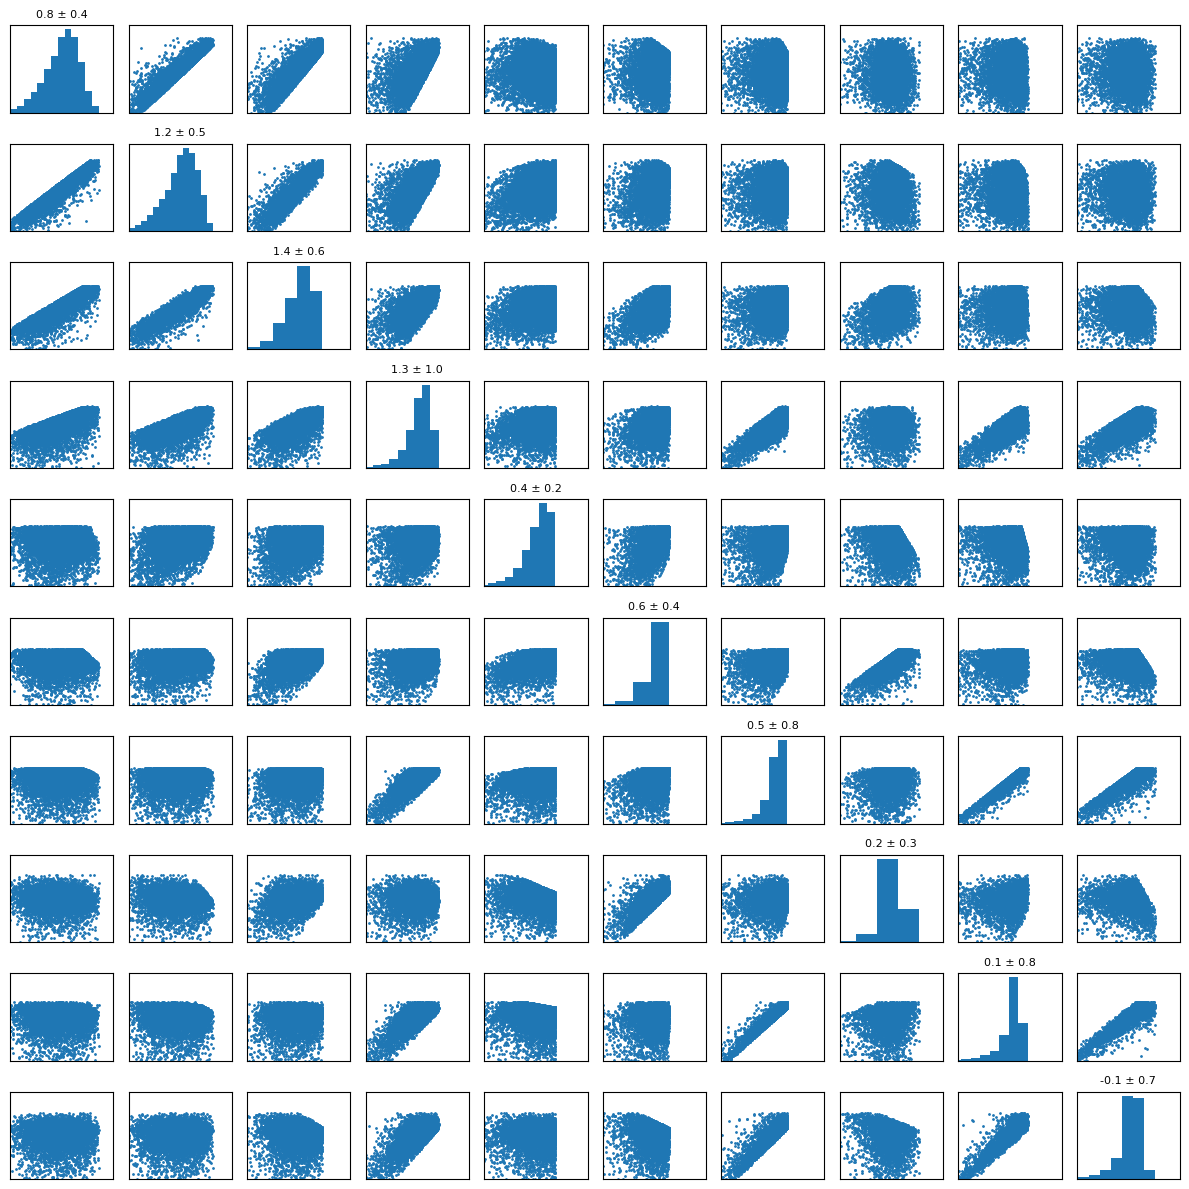

In [14]:
from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

# ------------------ LOAD DATA ------------------
hdul = fits.open("SDSS_DR17_galaxies.fits")
data = hdul[1].data

print("Available columns:", data.names)

# Try standard names
bands = ['u','g','r','i','z']

# Fallback if needed
if not all(b in data.names for b in bands):
    bands = ['modelMag_u','modelMag_g','modelMag_r','modelMag_i','modelMag_z']

print("Using bands:", bands)

# ------------------ FIX ENDIAN (NUMPY 2.0 SAFE) ------------------
def fix_endian(arr):
    return arr.byteswap().view(arr.dtype.newbyteorder('='))

df = pd.DataFrame({
    col: fix_endian(np.array(data[col]))
    for col in bands
})

# ------------------ FILTER BAD DATA ------------------
df = df[(df > 0).all(axis=1)]

# ------------------ CREATE COLOURS ------------------
colours = {}
for a, b in itertools.combinations(bands, 2):
    colours[f"{a}-{b}"] = df[a] - df[b]

col_df = pd.DataFrame(colours)

# ------------------ STATISTICS ------------------
means = col_df.mean()
stds = col_df.std()

# ------------------ CORNER PLOT ------------------
n = len(col_df.columns)
fig, axes = plt.subplots(n, n, figsize=(12, 12))

for i, col1 in enumerate(col_df.columns):
    for j, col2 in enumerate(col_df.columns):

        ax = axes[i, j]

        if i == j:
            ax.hist(col_df[col1], bins=30)

            mu = means[col1]
            sigma = stds[col1]

            ax.set_title(f"{mu:.1f} ± {sigma:.1f}", fontsize=8)
            ax.set_xlim(mu - 3*sigma, mu + 3*sigma)

        else:
            ax.scatter(col_df[col2], col_df[col1], s=1)

            ax.set_xlim(means[col2] - 3*stds[col2], means[col2] + 3*stds[col2])
            ax.set_ylim(means[col1] - 3*stds[col1], means[col1] + 3*stds[col1])

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

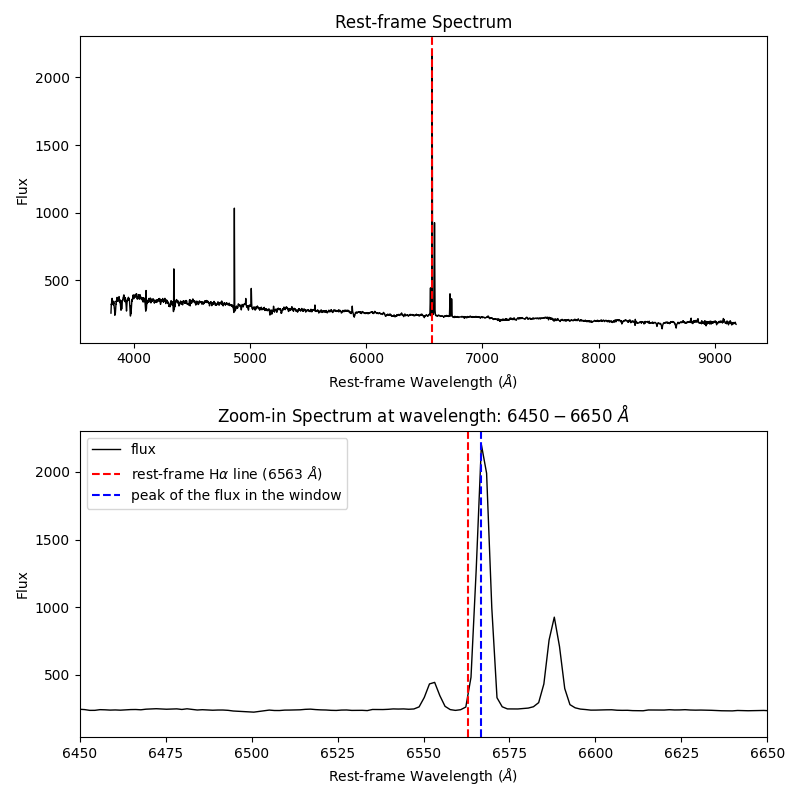

In [13]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import numpy as np
import matplotlib.pyplot as plt

# Coordinates
ra = 40.6696
dec = -0.0133
pos = coords.SkyCoord(ra, dec, unit="deg")

# Query
spec = SDSS.get_spectra(coordinates=pos, radius=10/3600)[0]

data = spec[1].data

flux = data['flux']
loglam = data['loglam']

lam = 10**loglam  # convert to linear scale

# Redshift correction
z = 0.0038
lam_rest = lam / (1 + z)

# H-alpha
H_alpha = 6563

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Full spectrum
ax1.plot(lam_rest, flux)
ax1.axvline(H_alpha, color='red', label='Hα')
ax1.set_title("Rest-frame spectrum")
ax1.legend()

# Zoomed spectrum
mask = (lam_rest > 6450) & (lam_rest < 6650)

ax2.plot(lam_rest[mask], flux[mask])
ax2.axvline(H_alpha, color='red', label='Hα')

# Peak detection
peak_lam = lam_rest[np.argmax(flux)]
ax2.axvline(peak_lam, color='green', label='Peak')

ax2.legend()

plt.tight_layout()
plt.show()

# Velocity calculation
c = 3e5  # km/s
delta_lambda = peak_lam - H_alpha

v = c * delta_lambda / H_alpha

print("Velocity (km/s):", v)

ModuleNotFoundError: No module named 'astroquery'

The global HI spectral profile corresponds exactly to the vertical line drawn in the PV diagram.

The PV diagram shows intensity as a function of Declination and velocity at a fixed Right Ascension. The vertical line at Dec = 40 selects one spatial position. The spectral profile is the intensity as a function of velocity at that same position.

Therefore, the spectral profile is a one-dimensional slice of the PV diagram along the velocity axis at the selected Declination.

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

/tmp/ipykernel_3443129/1461699984.py:12: RuntimeWarning: divide by zero encountered in log10
  data = np.log10(data + 1)


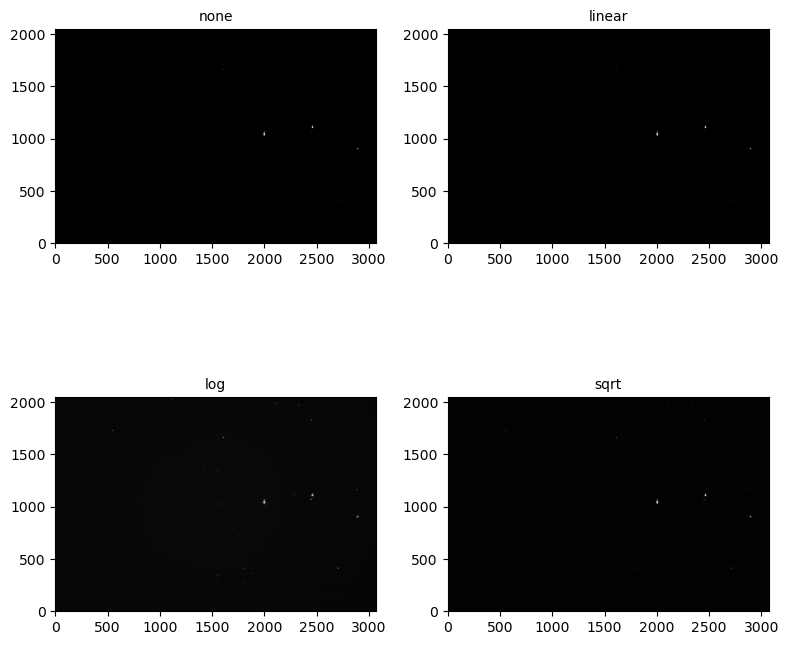

In [4]:
def imdisplay(data, stretch='linear'):
    """
    Display an image with different intensity stretches.

    Parameters:
    data : 2D array
        Image data
    stretch : str
        Type of stretch (linear, log, sqrt)
    """
    if stretch == 'log':
        data = np.log10(data + 1)
    elif stretch == 'sqrt':
        data = np.sqrt(data)

    return data

from astropy.io import fits

data = fits.getdata("20210422_Li_.00000066.FIT")

stretches = ['none', 'linear', 'log', 'sqrt']

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, s in zip(axes.flat, stretches):
    if s == 'none':
        img = data
    else:
        img = imdisplay(data, s)

    ax.imshow(img, cmap='gray', origin='lower')
    ax.set_title(s, fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

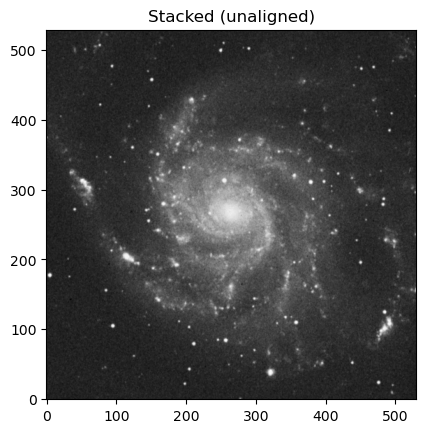

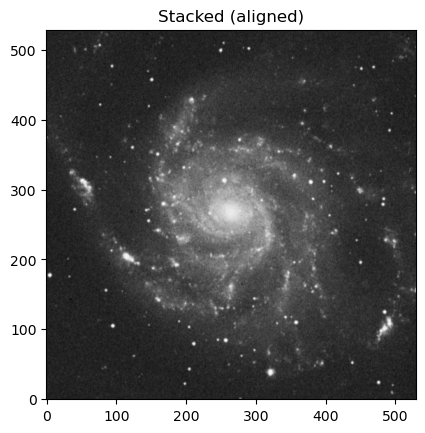

In [9]:
from glob import glob
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import shift

files = glob("*.fits")
images = [fits.getdata(f) for f in files]

# Keep only 2D images
images = [img for img in images if img.ndim == 2]

# Match shapes
shapes = [img.shape for img in images]
min_y = min(s[0] for s in shapes)
min_x = min(s[1] for s in shapes)

images = [img[:min_y, :min_x] for img in images]

# --- Unaligned stack ---
stack = np.mean(images, axis=0)

plt.imshow(stack, origin='lower', cmap='gray')
plt.title("Stacked (unaligned)")
plt.show()

# --- Alignment ---
aligned_images = []
ref = images[0]

y0, x0 = np.unravel_index(np.argmax(ref), ref.shape)

for img in images:
    y1, x1 = np.unravel_index(np.argmax(img), img.shape)

    dy = y0 - y1
    dx = x0 - x1

    aligned = shift(img, shift=(dy, dx))
    aligned_images.append(aligned)

stack_aligned = np.mean(aligned_images, axis=0)

plt.imshow(stack_aligned, origin='lower', cmap='gray')
plt.title("Stacked (aligned)")
plt.show()

The aligned stack shows sharper stars and less blurring compared to the unaligned stack. This demonstrates that misalignment causes artificial smearing, while alignment preserves spatial resolution.

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")